In [23]:
from pmdarima import auto_arima
import pandas as pd

In [12]:
# Test numpy years, which can be from 2016 to 2026
years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
# Test counts, which can be from 0 to 100
counts = [60, 67, 55, 52, 48, 44, 47, 40]

In [17]:
# Find best ARIMA parameters
auto_model = auto_arima(
    counts, 
    start_p=0, 
    max_p=3,
    start_q=0, 
    max_q=3,
    start_d=0, 
    max_d=2,
    seasonal=False,
    stepwise=True,
    trace=True,
    error_action='ignore'
)
print(auto_model.order)  # Returns (p, d, q)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=88.009, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=62.510, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=64.289, Time=0.11 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=63.440, Time=0.15 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.40 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=60.274, Time=0.30 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.11 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=58.267, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=60.487, Time=0.00 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=60.266, Time=0.15 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.21 sec

Best model:  ARIM

In [18]:
from statsmodels.tsa.arima.model import ARIMA

In [19]:
model = ARIMA(counts, order=(1, 1, 1))
fitted_model = model.fit()

c:\Users\drpri\VS projects\Python\Goose-Creek-Association-Database-Project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\drpri\VS projects\Python\Goose-Creek-Association-Database-Project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [25]:
# get the forecast of the fitted_model
forecast = fitted_model.get_forecast(steps=5)
forecast_df = forecast.summary_frame(alpha=0.05)  # 95% CI
forecast_df = forecast_df.rename(columns={'mean': 'forecast'})
forecast_df = forecast_df[['forecast', 'mean_ci_lower', 'mean_ci_upper']]
forecast_df

y,forecast,mean_ci_lower,mean_ci_upper
0,42.163947,29.987095,54.340798
1,40.954454,25.855615,56.053294
2,41.630475,23.099404,60.161545
3,41.252627,20.323115,62.182140
4,41.463817,18.138940,64.788694


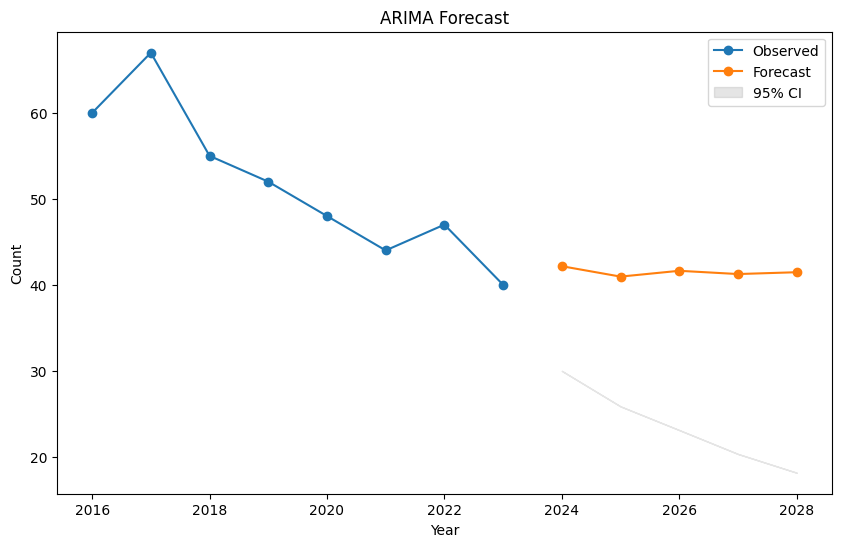

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(years, counts, label='Observed', marker='o')
# Create future years for the forecast
future_years = [2024, 2025, 2026, 2027, 2028]
plt.plot(future_years, forecast_df['forecast'], label='Forecast', marker='o')
plt.fill_between(future_years, forecast_df['mean_ci_lower'], forecast_df['mean_ci_lower'], color='gray', alpha=0.2, label='95% CI')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('ARIMA Forecast')
plt.legend()
plt.show()
